In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

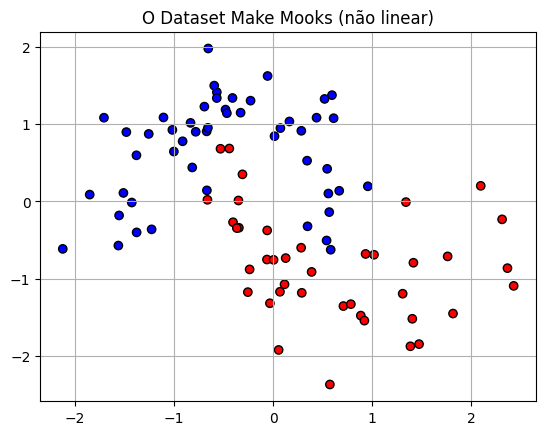

In [7]:
# -- Criar o dataset --- #
# --- noise adiciona ruído e dificulta a vida do algoritmo --- #
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# --- Dividir em treino e teste --- #
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    train_size=0.3,
    random_state=42
)

# --- Como o KNN e SVM dependem de distâncias, é obrigatório escalonar --- #
escalonador = StandardScaler()
X_treino = escalonador.fit_transform(X_treino)
X_teste = escalonador.transform(X_teste)
     

# --- Visulozar alguns dados --- #
plt.scatter(X_treino[:, 0], X_treino[:, 1], c=y_treino, cmap='bwr', edgecolor='k')
plt.title('O Dataset Make Mooks (não linear)')
plt.grid()
plt.show()

In [9]:
# --- KNN --- #
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)
knn_predicao = knn.predict(X_teste)

# --- SVM linear --- #
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_treino, y_treino)
svm_linear_predicao = svm_linear.predict(X_teste)

# --- SVM RBF --- #
svm_rbf = SVC(kernel='rbf', C=1)  # C é a rigidez da margem
svm_rbf.fit(X_treino, y_treino)
svm_rbf_predicao = svm_rbf.predict(X_teste)

# --- Mostrar a acurácia de cada modelo --- #
print(f'''KNN (K=5): {accuracy_score(y_teste, knn_predicao):.2%}
SVM Linear: {accuracy_score(y_teste, svm_linear_predicao):.2%}
SVM RBF: {accuracy_score(y_teste, svm_rbf_predicao):.2%}''')

KNN (K=5): 94.29%
SVM Linear: 87.14%
SVM RBF: 93.33%
